In [1]:
import pandas as pd
from fetch_data.config import config
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar os dados

In [2]:
df_ecommerce = pd.read_csv(os.path.join(config.DATA_PROCESSED, 'data_ecommerce.csv'))
df_mkt_funnel = pd.read_csv(os.path.join(config.DATA_PROCESSED, 'data_mkt_funnel.csv'))

In [4]:
df_ecommerce.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,seller_city,seller_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,128e10d95713541c87cd1a2e48201934,a20e8105f23924cd00833fd87daa0831,delivered,2017-08-15 18:29:31,2017-08-15 20:05:16,2017-08-17 15:28:33,2017-08-18 14:44:43,2017-08-28 00:00:00,1,credit_card,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
4,0e7e841ddf8f8f2de2bad69267ecfbcf,26c7ac168e1433912a51b924fbd34d34,delivered,2017-08-02 18:24:47,2017-08-02 18:43:15,2017-08-04 17:35:43,2017-08-07 18:30:01,2017-08-15 00:00:00,1,credit_card,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0


In [5]:
df_mkt_funnel.head()

,mql_id,first_contact_date,landing_page_id,origin,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,...,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,...,NaN,reseller,NaN,0.0,1efcc6ba75b519535a510c53153a9256,1.0,e94df75b2e9a8b056be0c144a731f55c,2018-06-26 22:20:21,94.2,18.76


In [7]:
df_ecommerce.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'seller_zip_code_prefix', 'seller_city',
       'seller_state', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [8]:
df_mkt_funnel.columns

Index(['mql_id', 'first_contact_date', 'landing_page_id', 'origin',
       'seller_id', 'sdr_id', 'sr_id', 'won_date', 'business_segment',
       'lead_type', 'lead_behaviour_profile', 'has_company', 'has_gtin',
       'average_stock', 'business_type', 'declared_product_catalog_size',
       'declared_monthly_revenue', 'order_id', 'order_item_id', 'product_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

# Datasets infos

In [9]:
df_ecommerce.shape

(118315, 39)

In [10]:
df_mkt_funnel.shape

(12664, 23)

### Check NA rows

In [7]:
df_ecommerce.isna().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                    15
order_delivered_carrier_date       1254
order_delivered_customer_date      2588
order_estimated_delivery_date         0
payment_sequential                    0
payment_type                          0
payment_installments                  0
payment_value                         0
review_id                             0
review_score                          0
review_comment_title             104226
review_comment_message            67650
review_creation_date                  0
review_answer_timestamp               0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                         0
product_id                            0
seller_id                             0


In [4]:
df_mkt_funnel.isna().sum()

mql_id                               0
first_contact_date                   0
landing_page_id                      0
origin                              67
seller_id                         7158
sdr_id                            7158
sr_id                             7158
won_date                          7158
business_segment                  7159
lead_type                         7209
lead_behaviour_profile            8985
has_company                      12576
has_gtin                         12575
average_stock                    12573
business_type                     7170
declared_product_catalog_size    12595
declared_monthly_revenue          7158
order_id                          7620
order_item_id                     7620
product_id                        7620
shipping_limit_date               7620
price                             7620
freight_value                     7620
dtype: int64

### Change data types

In [3]:
# get cols to transform to date
cols_to_date = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date'
               ,'order_estimated_delivery_date','review_creation_date', 'review_answer_timestamp', 'shipping_limit_date']

#removing the timestamp from date
for col in cols_to_date:
    df_ecommerce[col] = pd.to_datetime(pd.to_datetime(df_ecommerce[col]).dt.date)

In [85]:
df_ecommerce[cols_to_date].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
review_creation_date             datetime64[ns]
review_answer_timestamp          datetime64[ns]
shipping_limit_date              datetime64[ns]
dtype: object

### Descriptive Statistics

In [14]:
df_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118315 entries, 0 to 118314
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118315 non-null  object 
 1   customer_id                    118315 non-null  object 
 2   order_status                   118315 non-null  object 
 3   order_purchase_timestamp       118315 non-null  object 
 4   order_approved_at              118300 non-null  object 
 5   order_delivered_carrier_date   117061 non-null  object 
 6   order_delivered_customer_date  115727 non-null  object 
 7   order_estimated_delivery_date  118315 non-null  object 
 8   payment_sequential             118315 non-null  int64  
 9   payment_type                   118315 non-null  object 
 10  payment_installments           118315 non-null  int64  
 11  payment_value                  118315 non-null  float64
 12  review_id                     

In [16]:
df_ecommerce.describe().T

,count,mean,std,min,25%,50%,75%,max
payment_sequential,118315.0,1.094062,0.728555,1.00,1.00,1.00,1.00,29.00
payment_installments,118315.0,2.943498,2.778022,0.00,1.00,2.00,4.00,24.00
payment_value,118315.0,172.575651,267.104661,0.00,60.85,108.20,189.26,13664.08
review_score,118315.0,4.014554,1.400186,1.00,3.00,5.00,5.00,5.00
customer_zip_code_prefix,118315.0,35051.681579,29824.811223,1003.00,11310.00,24310.00,58640.00,99990.00
order_item_id,118315.0,1.196509,0.699452,1.00,1.00,1.00,1.00,21.00
price,118315.0,120.651027,184.109626,0.85,39.90,74.90,134.90,6735.00
freight_value,118315.0,20.033024,15.836523,0.00,13.08,16.28,21.18,409.68
seller_zip_code_prefix,118315.0,24440.790703,27571.679456,1001.00,6429.00,13660.00,27946.50,99730.00
product_name_lenght,116606.0,48.767782,10.033375,5.00,42.00,52.00,57.00,76.00


In [15]:
df_mkt_funnel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12664 entries, 0 to 12663
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   mql_id                         12664 non-null  object 
 1   first_contact_date             12664 non-null  object 
 2   landing_page_id                12664 non-null  object 
 3   origin                         12597 non-null  object 
 4   seller_id                      5506 non-null   object 
 5   sdr_id                         5506 non-null   object 
 6   sr_id                          5506 non-null   object 
 7   won_date                       5506 non-null   object 
 8   business_segment               5505 non-null   object 
 9   lead_type                      5455 non-null   object 
 10  lead_behaviour_profile         3679 non-null   object 
 11  has_company                    88 non-null     object 
 12  has_gtin                       89 non-null    

In [17]:
df_mkt_funnel.describe().T

,count,mean,std,min,25%,50%,75%,max
declared_product_catalog_size,69.0,233.028986,352.380558,1.0,30.0000,100.000,300.00,2000.00
declared_monthly_revenue,5506.0,11221.214312,682480.502851,0.0,0.0000,0.000,0.00,50000000.00
order_item_id,5044.0,1.170896,0.575577,1.0,1.0000,1.000,1.00,7.00
price,5044.0,134.189429,211.746414,2.2,43.8625,93.995,139.00,3899.00
freight_value,5044.0,19.620172,19.133071,0.0,12.2400,16.510,20.44,306.06


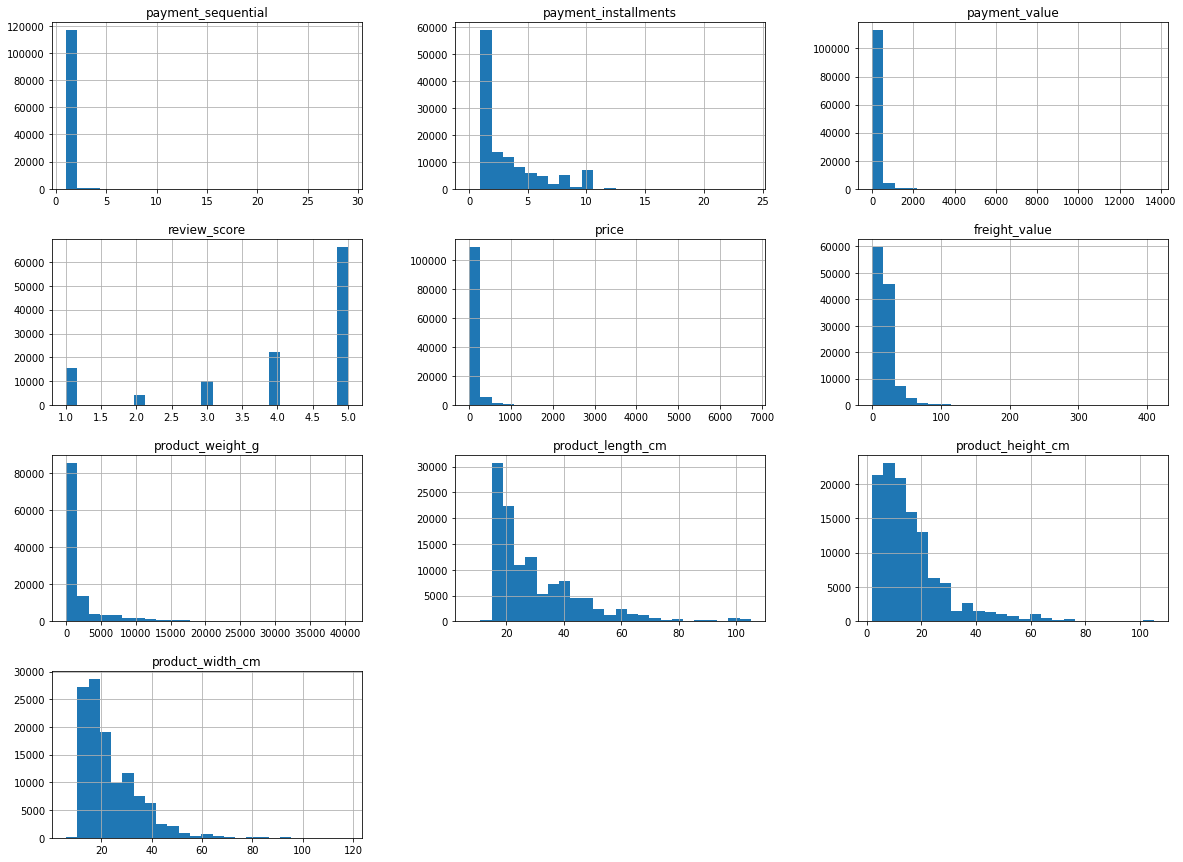

In [25]:
df_ecommerce[['payment_sequential', 'payment_installments', 'payment_value' ,'review_score', 'price', 'freight_value', 'product_weight_g' , 'product_length_cm' , 'product_height_cm' , 'product_width_cm']].hist( bins=25, figsize=(20,15) );

In [27]:
df_ecommerce[['order_status', 'payment_type', 'customer_city', 'customer_state', 'seller_city', 'seller_state', 'product_category_name']].describe()

,order_status,payment_type,customer_city,customer_state,seller_city,seller_state,product_category_name
count,118315,118315,118315,118315,118315,118315,116606
unique,7,4,4110,27,611,23,73
top,delivered,credit_card,sao paulo,SP,sao paulo,SP,cama_mesa_banho
freq,115728,87266,18728,49865,29294,84384,11990


In [30]:
df_mkt_funnel[['origin', 'business_segment', 'business_type', 'lead_type', 'lead_behaviour_profile', 'has_company', 'has_gtin']].describe()

,origin,business_segment,business_type,lead_type,lead_behaviour_profile,has_company,has_gtin
count,12597,5505,5494,5455,3679,88,89
unique,10,33,3,8,9,2,2
top,organic_search,health_beauty,reseller,online_medium,cat,True,True
freq,3529,869,4662,2148,2152,59,79


# Feature engineering

![](https://github.com/mathdeoliveira/olist/blob/dev/notebooks/images/mind_map.jpg?raw=true)

## Hypothesis

### Hypothesis customers

- Clientes que tiveram os seus pedidos enviados após a data da estimativa de entrega não voltam a comprar
- Clientes de SP são os que tem o maior volume de compra
- Clientes que compram com cartão de crédito compra mais que do que aqueles que compram com boleto
- Clientes que tiveram as suas compras canceladas não voltam a comprar
- Clientes que pagam alto valor de frete compram diversos produtos

### Hypothesis Product
- Produtos com peso abaixo do primeiro quartil são os mais vendidos em termos de quantidade
- Categoria do produto mais vendido é aquela relacionada a eletrônicos, pois o valor agregado é alto
- Os produtos que tem mais fotos publicadas são os mais vendidos em termos de valor
- Produtos com nome longos são menos vendidos
- Produtos com descrição longas são os mais vendidos
- Produtos com grandes dimensões(altura, peso, largura...) são menos vendidos, porém tem alto retorno pro negócio

### Hypothesis Sellers
- Vendedores de SP são os que mais atrasam os envios
- Os melhores vendedores, de acordo com a nota do review, são os que mais vendem produtos

### Hypothesis Payments
- Todas as compras feitas foram parceladas em 2x
- Quanto mais alta são as notas dos reviews menor as parcelas
- Cartão de crédito é o método de pagamento que mais atrasa o envio para transportadora

### Hypothesis Time
- A maioria das compras são feitas antes do dia 15
- Há um aumento no valor de vendas aprovadas no mês de dezembro

### Hypothesis markerting funnel
- Os leads que não fecharam o negócio são os que foram adquiridos por pesquisa orgânica
- Os leads que tem uma empresa formal são a maioria que fecham o negócio

## Feature engineering

In [4]:
df_ecommerce_engi = df_ecommerce.copy()

In [5]:
df_ecommerce_engi.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,seller_city,seller_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,2017-10-02,2017-10-04,2017-10-10,2017-10-18,1,credit_card,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,2017-10-02,2017-10-04,2017-10-10,2017-10-18,3,voucher,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,2017-10-02,2017-10-04,2017-10-10,2017-10-18,2,voucher,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,128e10d95713541c87cd1a2e48201934,a20e8105f23924cd00833fd87daa0831,delivered,2017-08-15,2017-08-15,2017-08-17,2017-08-18,2017-08-28,1,credit_card,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
4,0e7e841ddf8f8f2de2bad69267ecfbcf,26c7ac168e1433912a51b924fbd34d34,delivered,2017-08-02,2017-08-02,2017-08-04,2017-08-07,2017-08-15,1,credit_card,...,maua,SP,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0


### Fillout missing values

#### Categorical and dates variables

In [6]:
# make a list of the categorical variables that contain missing values

vars_with_na = [
    var for var in df_ecommerce_engi.columns
    if df_ecommerce_engi[var].isnull().sum() > 0 and df_ecommerce_engi[var].dtypes == 'object' 
]

# print percentage of missing values per variable
df_ecommerce_engi[vars_with_na].isnull().mean()

review_comment_title      0.880920
review_comment_message    0.571779
product_category_name     0.014444
dtype: float64

In [7]:
# make a list of the categorical variables that contain missing values

vars_with_na = [
    var for var in df_ecommerce_engi.columns
    if df_ecommerce_engi[var].isnull().sum() > 0 and df_ecommerce_engi[var].dtypes == 'datetime64[ns]'
]

# print percentage of missing values per variable
df_ecommerce_engi[vars_with_na].isnull().mean()

order_approved_at                0.000127
order_delivered_carrier_date     0.010599
order_delivered_customer_date    0.021874
dtype: float64

Para as colunas relacionadas ao review, como o título e a mensagem, vamos deletar essas duas colunas pois nesse projeto não iremos lidar com NLP. Agora, para o nome da categoria do produto vamos substituir os valores faltantes por 'missing'.

Agora para as colunas com o tipo data, essas linhas serão deletadas, já que representa uma porcentagem bem pouca sobre todo o dataset.

In [8]:
# dropping this columns, too many rows with nan values
df_ecommerce_engi.drop(['review_comment_title', 'review_comment_message'], inplace = True, axis = 1)

# drop nan rows
df_ecommerce_engi.dropna(subset=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date'], axis = 0
                    , inplace = True)

# replace null values with missing
df_ecommerce_engi['product_category_name'].fillna('missing', inplace=True)

#### Numerical variables

In [9]:
# make a list of the categorical variables that contain missing values

vars_with_na = [
    var for var in df_ecommerce_engi.columns
    if df_ecommerce_engi[var].isnull().sum() > 0 and df_ecommerce_engi[var].dtypes != 'object' and df_ecommerce_engi[var].dtypes != 'datetime64[ns]' 
]

# print percentage of missing values per variable
df_ecommerce_engi[vars_with_na].isnull().mean()

product_name_lenght           0.014147
product_description_lenght    0.014147
product_photos_qty            0.014147
product_weight_g              0.000173
product_length_cm             0.000173
product_height_cm             0.000173
product_width_cm              0.000173
dtype: float64

Para as colunas númericas:
- adicionar uma coluna indicando que existia valores faltantes
- substituir os valores faltantes pela moda na coluna original

In [10]:
# replace engineer missing values as we described above

for var in vars_with_na:

    # calculate the mode using the train set
    mode_val = df_ecommerce_engi[var].mode()[0]

    # add binary missing indicator (in train and test)
    df_ecommerce_engi[var+'_na'] = np.where(df_ecommerce_engi[var].isnull(), 1, 0)

    # replace missing values by the mode
    # (in train and test)
    df_ecommerce_engi[var] = df_ecommerce_engi[var].fillna(mode_val)

# check that we have no more missing values in the engineered variables
df_ecommerce_engi[vars_with_na].isnull().sum()

product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [93]:
# check that dataset does not contain null values in the engineered variables

[vr for var in vars_with_na if df_ecommerce_engi[var].isnull().sum() > 0]

[]

In [94]:
# check the binary missing indicator variables
df_ecommerce_engi[['product_name_lenght_na', 'product_description_lenght_na']].tail()

,product_name_lenght_na,product_description_lenght_na
118307,0,0
118310,0,0
118312,0,0
118313,0,0
118314,0,0


In [95]:
df_ecommerce_engi.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
payment_sequential               0
payment_type                     0
payment_installments             0
payment_value                    0
review_id                        0
review_score                     0
review_creation_date             0
review_answer_timestamp          0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
seller_zip_code_prefix           0
seller_city                      0
seller_state        

# Exploratory data analysis

## Univariate analysis

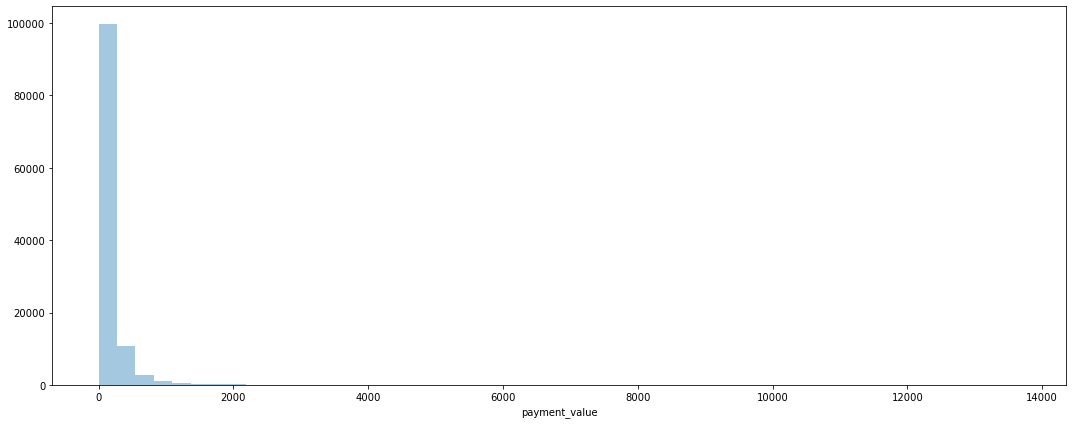

In [133]:
plt.figure(figsize=(15,6))
sns_plot = sns.distplot(df_ecommerce_engi['payment_value'], kde=False)
plt.tight_layout()
sns_plot.figure.savefig("images/payment_dist.png")

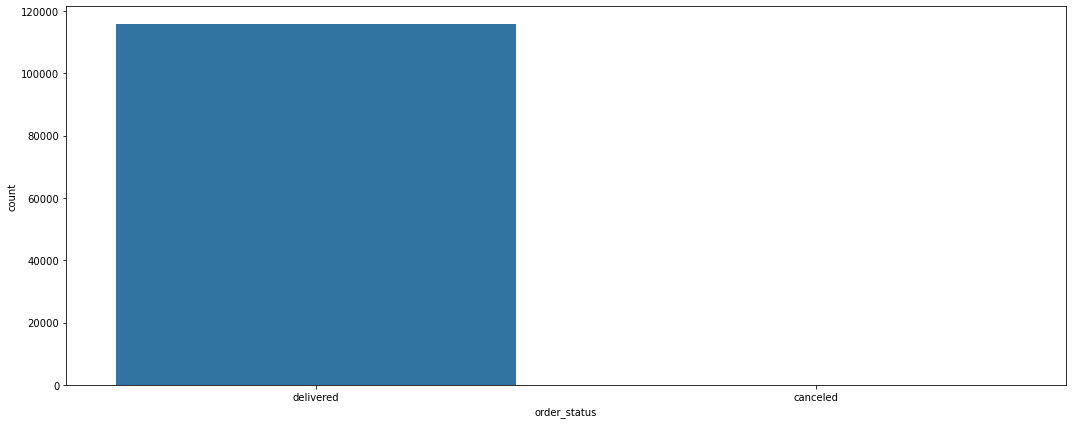

In [137]:
plt.figure(figsize=(15,6))
sns_plot = sns.countplot(x='order_status', data=df_ecommerce_engi)
plt.tight_layout()
sns_plot.figure.savefig("images/order_status_count.png")

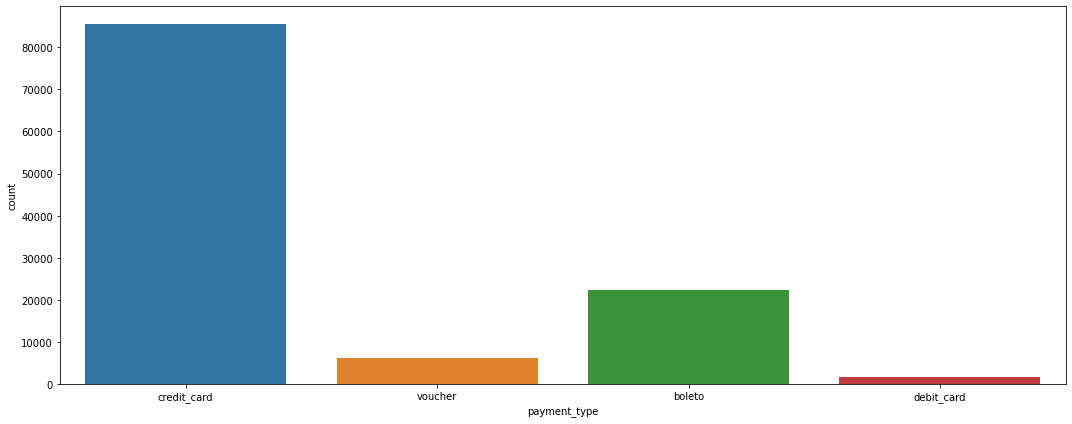

In [136]:
plt.figure(figsize=(15,6))
sns_plot = sns.countplot(x='payment_type', data=df_ecommerce_engi)
plt.tight_layout()
sns_plot.figure.savefig("images/payment_type_count.png")

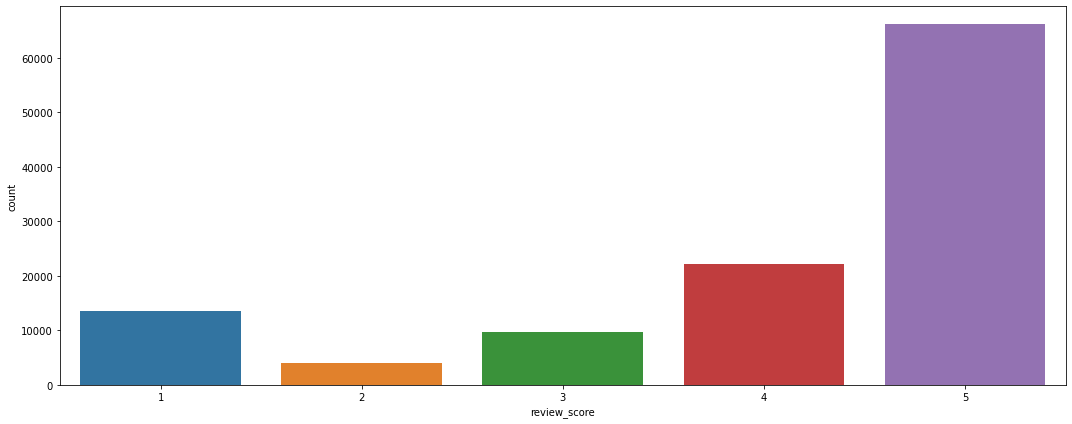

In [135]:
plt.figure(figsize=(15,6))
sns_plot = sns.countplot(x='review_score', data=df_ecommerce_engi)
plt.tight_layout()
sns_plot.figure.savefig("images/review_score_count.png")

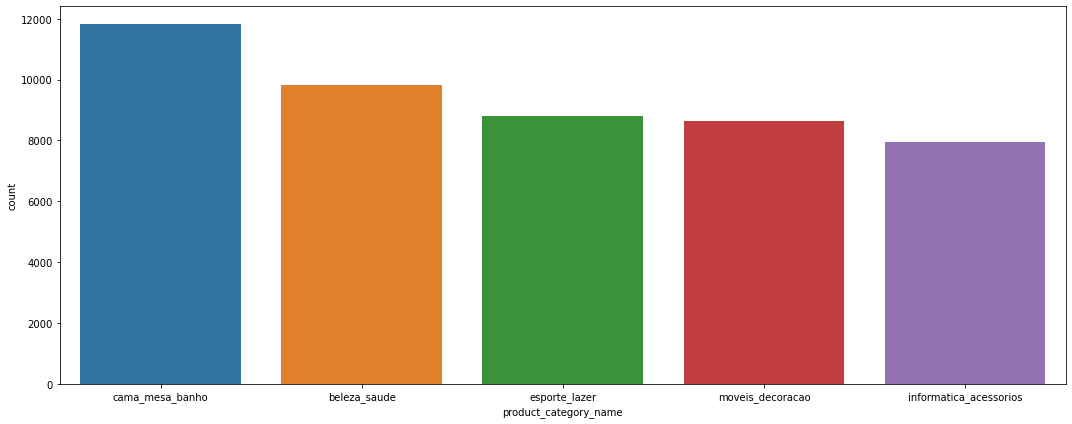

In [134]:
plt.figure(figsize=(15,6))
sns_plot = sns.countplot(x='product_category_name', data=df_ecommerce_engi, order=df_ecommerce_engi.product_category_name.value_counts().iloc[:5].index)
plt.tight_layout()
sns_plot.figure.savefig("images/product_category_name_count.png")

## Bivariate analysis

**H1. Clientes que tiveram os seus pedidos enviados após a data da estimativa de entrega não voltam a comprar**

In [11]:
h1 = df_ecommerce_engi[['customer_unique_id', 'order_delivered_customer_date', 'order_estimated_delivery_date']].copy()
h1.head()

,customer_unique_id,order_delivered_customer_date,order_estimated_delivery_date
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-10,2017-10-18
1,7c396fd4830fd04220f754e42b4e5bff,2017-10-10,2017-10-18
2,7c396fd4830fd04220f754e42b4e5bff,2017-10-10,2017-10-18
3,3a51803cc0d012c3b5dc8b7528cb05f7,2017-08-18,2017-08-28
4,ef0996a1a279c26e7ecbd737be23d235,2017-08-07,2017-08-15


In [12]:
h1 = h1.groupby(['customer_unique_id','order_delivered_customer_date', 'order_estimated_delivery_date']).first().reset_index()

In [13]:
h1['delay_delivered_estimated'] = h1.apply(lambda x : 1 if x['order_delivered_customer_date']> x['order_estimated_delivery_date'] else 0, axis=1)

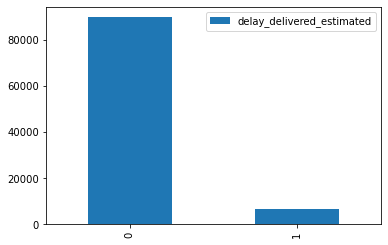

In [15]:
sns_plot = h1.delay_delivered_estimated.value_counts().plot(kind = 'bar', legend = True)
sns_plot.figure.savefig("images/h1.png")

In [52]:
h1.loc[h1['customer_unique_id']==h1['customer_unique_id'].loc[h1['customer_unique_id'].isin(h1['customer_unique_id'].loc[h1['delay_delivered_estimated']==1])].loc[h1['delay_delivered_estimated']==0].iloc[0]]

,customer_unique_id,order_delivered_customer_date,order_estimated_delivery_date,delay_delivered_estimated
779,02168ea18740a0fdaaa15f11bebba5db,2017-09-23,2017-09-15,1
780,02168ea18740a0fdaaa15f11bebba5db,2017-10-20,2017-11-08,0


No gráfico temos que existe sim clientes que receberam os seus produtos após a data de estimativa, então houve algum tipo de atraso. Como a nossa hipótese levantada diz que os clientes tiveram os seus pedidos enviados após a data da estimativa de entrega não voltam a comprar, vamos capturar um exemplo da base onde o cliente comprou e teve atraso e após esse atraso voltou a comprar.

Vemos que na tabela existe um cliente que comprou com atraso e voltar a comprar logo após a compra, assim a hipótese é FALSA.

**H2. Clientes de SP são os que tem o maior volume de compra**

In [17]:
h2 = df_ecommerce_engi[['customer_state', 'payment_value']].copy()

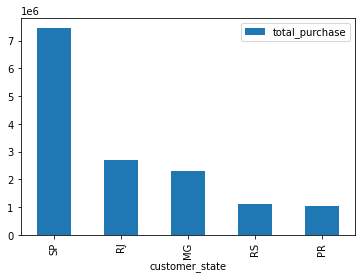

In [18]:
sns_plot = h2.groupby('customer_state').agg(total_purchase=('payment_value', 'sum')).sort_values('total_purchase', ascending = False).head(5).plot(kind = 'bar', legend = True);
sns_plot.figure.savefig("images/h2.png")

Fica evidente que a hipótese é verdadeira, tanto é que, a cidade RJ tem 63% menos em volume de venda do que SP. Em outras palavras, SP vende mais que o dobro da segunda colocada.

**H3. Clientes que compram com cartão de crédito compra mais que do que aqueles que compram com boleto**

In [19]:
h3 = df_ecommerce_engi[['payment_type', 'payment_value']].copy()

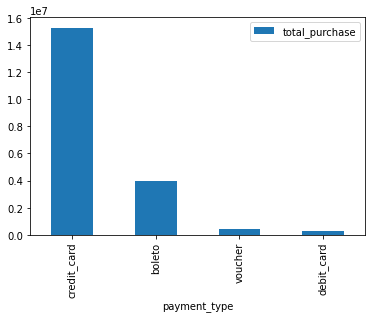

In [20]:
sns_plot = h3.groupby('payment_type').agg(total_purchase=('payment_value', 'sum')).sort_values('total_purchase', ascending = False).plot(kind = 'bar', legend = True);
sns_plot.figure.savefig("images/h3.png")

In [136]:
round(df_ecommerce.payment_value.sum(),2)

20418288.15

Novamente, é uma hipótese verdadeira, vemos que o método de pagamento cartão de crédito é o mais utilizado do que os outros, do total de venda de 20.418.288,15, o cartão de crédito foi responsável por 15.670.920,67 das vendas da empresa representando 76% do total.

**H4. Clientes que tiveram as suas compras canceladas não voltam a comprar**

In [21]:
h4 = df_ecommerce_engi[['order_purchase_timestamp', 'customer_unique_id', 'order_status']].copy()
h4.head()

,order_purchase_timestamp,customer_unique_id,order_status
0,2017-10-02,7c396fd4830fd04220f754e42b4e5bff,delivered
1,2017-10-02,7c396fd4830fd04220f754e42b4e5bff,delivered
2,2017-10-02,7c396fd4830fd04220f754e42b4e5bff,delivered
3,2017-08-15,3a51803cc0d012c3b5dc8b7528cb05f7,delivered
4,2017-08-02,ef0996a1a279c26e7ecbd737be23d235,delivered


In [205]:
df_ecommerce_engi.order_status.value_counts()

delivered    115704
canceled          7
Name: order_status, dtype: int64

In [22]:
h4 = h4.groupby(['order_purchase_timestamp', 'customer_unique_id','order_status']).first().reset_index()

In [23]:
h4.loc[h4['customer_unique_id'].isin(h4['customer_unique_id'].loc[h4['order_status']=='canceled'])].loc[h4['order_status']=='delivered']

,order_purchase_timestamp,customer_unique_id,order_status


In [24]:
test_customer_canceled = h4['customer_unique_id'].loc[h4['order_status']=='canceled'].to_list()

In [25]:
df_ecommerce_engi.loc[df_ecommerce_engi['customer_unique_id'].isin(test_customer_canceled)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,product_length_cm,product_height_cm,product_width_cm,product_name_lenght_na,product_description_lenght_na,product_photos_qty_na,product_weight_g_na,product_length_cm_na,product_height_cm_na,product_width_cm_na
19081,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03,2016-10-04,2016-10-25,2016-11-08,2016-11-25,1,credit_card,...,17.0,14.0,14.0,0,0,0,0,0,0,0
45232,8beb59392e21af5eb9547ae1a9938d06,bf609b5741f71697f65ce3852c5d2623,canceled,2016-10-08,2016-10-09,2016-10-14,2016-10-19,2016-11-30,1,credit_card,...,22.0,50.0,32.0,0,0,0,0,0,0,0
48368,770d331c84e5b214bd9dc70a10b829d0,6c57e6119369185e575b36712766b0ef,canceled,2016-10-07,2016-10-07,2016-10-11,2016-10-14,2016-11-29,1,credit_card,...,22.0,14.0,16.0,0,0,0,0,0,0,0
48409,dabf2b0e35b423f94618bf965fcb7514,5cdec0bb8cbdf53ffc8fdc212cd247c6,canceled,2016-10-09,2016-10-09,2016-10-13,2016-10-16,2016-11-30,1,credit_card,...,20.0,20.0,20.0,0,0,0,0,0,0,0
48689,dabf2b0e35b423f94618bf965fcb7514,5cdec0bb8cbdf53ffc8fdc212cd247c6,canceled,2016-10-09,2016-10-09,2016-10-13,2016-10-16,2016-11-30,1,credit_card,...,20.0,15.0,17.0,0,0,0,0,0,0,0
48960,1950d777989f6a877539f53795b4c3c3,1bccb206de9f0f25adc6871a1bcf77b2,canceled,2018-02-19,2018-02-19,2018-02-20,2018-03-21,2018-03-09,1,credit_card,...,20.0,11.0,17.0,0,0,0,0,0,0,0
80042,2c45c33d2f9cb8ff8b1c86cc28c11c30,de4caa97afa80c8eeac2ff4c8da5b72e,canceled,2016-10-09,2016-10-10,2016-10-14,2016-11-09,2016-12-08,1,credit_card,...,22.0,15.0,20.0,0,0,0,0,0,0,0


Essa hipótese é verdadeira, porém devemos levar em consideração que existe uma quantidade bem pouca sobre os clientes que cancelaram suas compras, das 115.711 orders, somente 7 clientes tem status cancelado. Por isso devemos capturar mais dados para realmente provar essa hipótese.

**H5. Clientes que pagam alto valor de frete compram diversos produtos**

In [26]:
h5 = df_ecommerce_engi[['customer_unique_id', 'product_id','freight_value']].copy()
h5.head()

,customer_unique_id,product_id,freight_value
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,8.72
1,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,8.72
2,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,8.72
3,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,7.78
4,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,7.78


In [27]:
h5 = h5.groupby(['customer_unique_id', 'product_id']).agg(qty_product=('product_id', 'count'), total_fright_value=('freight_value', 'sum')).reset_index()

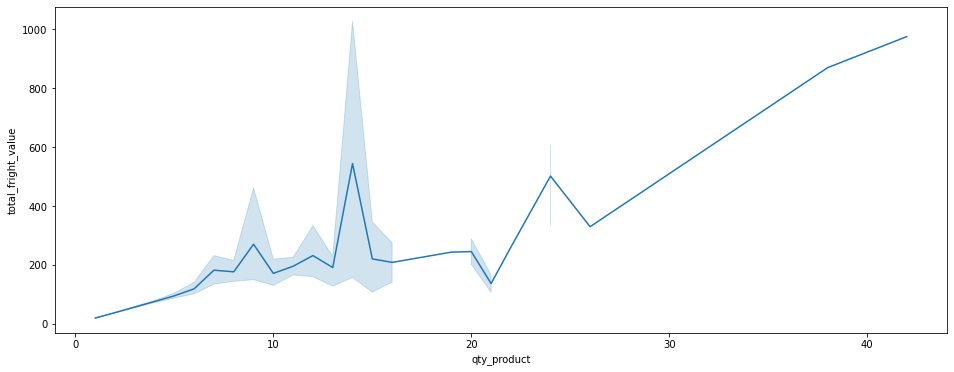

In [28]:
plt.figure(figsize=(16, 6))
sns_plot = sns.lineplot(data=h5, x="qty_product", y="total_fright_value");
sns_plot.figure.savefig("images/h5.png")

Hipótese verdadeira, mesmo que tenha algumas quedas na quantidade de produtos vs total pago pelo frete, quanto maior a quantidade de produtos distintos comprados maior é o valor do frete.

**H6. Produtos com peso abaixo do primeiro quartil são os mais vendidos em termos de quantidade**

In [29]:
h6 = df_ecommerce_engi[['product_id' , 'product_weight_g']]
h6.head(10)

,product_id,product_weight_g
0,87285b34884572647811a353c7ac498a,500.0
1,87285b34884572647811a353c7ac498a,500.0
2,87285b34884572647811a353c7ac498a,500.0
3,87285b34884572647811a353c7ac498a,500.0
4,87285b34884572647811a353c7ac498a,500.0
5,87285b34884572647811a353c7ac498a,500.0
6,b00a32a0b42fd65efb58a5822009f629,238.0
7,b00a32a0b42fd65efb58a5822009f629,238.0
8,b00a32a0b42fd65efb58a5822009f629,238.0
9,b00a32a0b42fd65efb58a5822009f629,238.0


In [30]:
h6_1 = h6.loc[h6['product_weight_g'] < 300].groupby('product_id').agg(qty_product=('product_id', 'count')).reset_index()
h6_1.qty_product.sum()

28071

In [31]:
h6_2 = h6.loc[h6['product_weight_g'] > 300].groupby('product_id').agg(qty_product=('product_id', 'count')).reset_index()
h6_2.qty_product.sum()

83316

Sabemos que o primeiro quartil para a variável é ate 300 gramas, para tal, tivemos 28.071 vendas dos produtos abaixo de 300 gramas e para acima de 300 gramas tivemos 83.316, por isso a hipótese é falsa, produtos mais pesados que 300 gramas tem a maior quantidade vendida.

**H7. Categoria do produto mais vendido é aquela relacionada a eletrônicos, pois o valor agregado é alto**

In [32]:
h7 = df_ecommerce_engi[['product_id', 'product_category_name', 'payment_value']].copy()
h7.head()

,product_id,product_category_name,payment_value
0,87285b34884572647811a353c7ac498a,utilidades_domesticas,18.12
1,87285b34884572647811a353c7ac498a,utilidades_domesticas,2.00
2,87285b34884572647811a353c7ac498a,utilidades_domesticas,18.59
3,87285b34884572647811a353c7ac498a,utilidades_domesticas,37.77
4,87285b34884572647811a353c7ac498a,utilidades_domesticas,37.77


In [33]:
h7 = h7.groupby(['product_id', 'product_category_name']).agg(total_payment=('payment_value', 'sum')).reset_index().sort_values('total_payment', ascending = False).head(10)

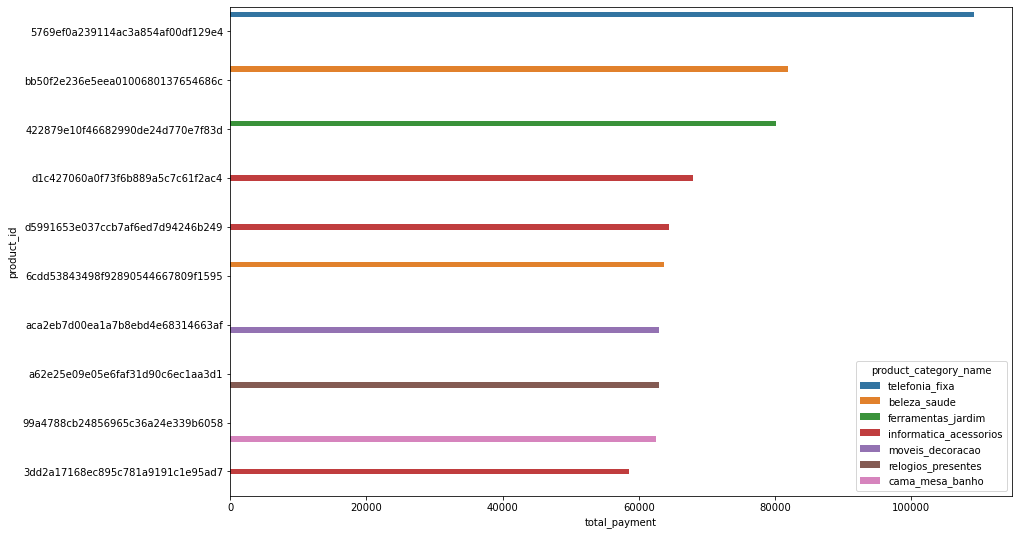

In [34]:
plt.figure(figsize=(14, 9))
sns_plot = sns.barplot(x="total_payment", y="product_id", hue="product_category_name", data=h7);
sns_plot.figure.savefig("images/h7.png")

Para os dez primeiros, podemos parcialmente retirar algumas informações já que não temos um campo falando exatamente qual universo o produto se encontra. O produto com o maior valor vendido é relacionado a telefonia fixa, que em maior parte é um eletrônico, também vemos a categoria informática e acessórios, que também é eletrônicos, podemos confirmar essa hipótese, mas com atenção mostrando que existe outras categoria que também vende bem.

**H8. Os produtos que tem mais fotos publicadas são os mais vendidos em termos de valor**

In [35]:
h8 = df_ecommerce_engi[['product_id', 'product_photos_qty', 'payment_value']].copy()
h8.head()

,product_id,product_photos_qty,payment_value
0,87285b34884572647811a353c7ac498a,4.0,18.12
1,87285b34884572647811a353c7ac498a,4.0,2.00
2,87285b34884572647811a353c7ac498a,4.0,18.59
3,87285b34884572647811a353c7ac498a,4.0,37.77
4,87285b34884572647811a353c7ac498a,4.0,37.77


In [36]:
h8 = h8.groupby('product_id').agg(product_photos_qty=('product_photos_qty', 'max'), total_value=('payment_value', 'sum')).reset_index()

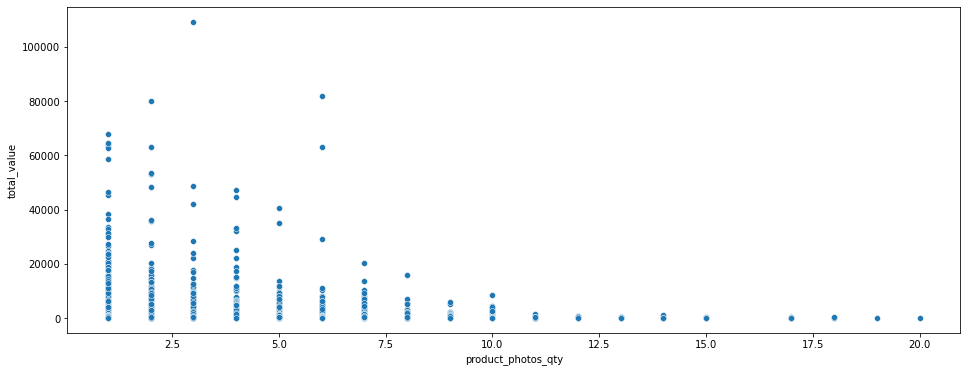

In [37]:
plt.figure(figsize=(16, 6))
sns_plot = sns.scatterplot(data=h8, x="product_photos_qty", y="total_value");
sns_plot.figure.savefig("images/h8.png")

Hipótese falsa, não há evidências suficientes que quanto maior a quantidade de fotos publicada do produto, maior é o valor da venda, o gráfico ilustra uma queda no total vendido enquanto a quantidade de fotos publicadas aumenta, pode levar em consideração que o produto que tem 20 fotos publicadas teve total de vendas abaixo do que o produto com 19 fotos publicada.

**H9. Produtos com nome longos são menos vendidos**

In [38]:
h9 = df_ecommerce_engi[['product_id', 'product_name_lenght']].copy()
h9.head()

,product_id,product_name_lenght
0,87285b34884572647811a353c7ac498a,40.0
1,87285b34884572647811a353c7ac498a,40.0
2,87285b34884572647811a353c7ac498a,40.0
3,87285b34884572647811a353c7ac498a,40.0
4,87285b34884572647811a353c7ac498a,40.0


In [39]:
h9 = h9.groupby('product_id').agg(name_lenght=('product_name_lenght', 'first'), qty_purchase=('product_id', 'count')).reset_index()

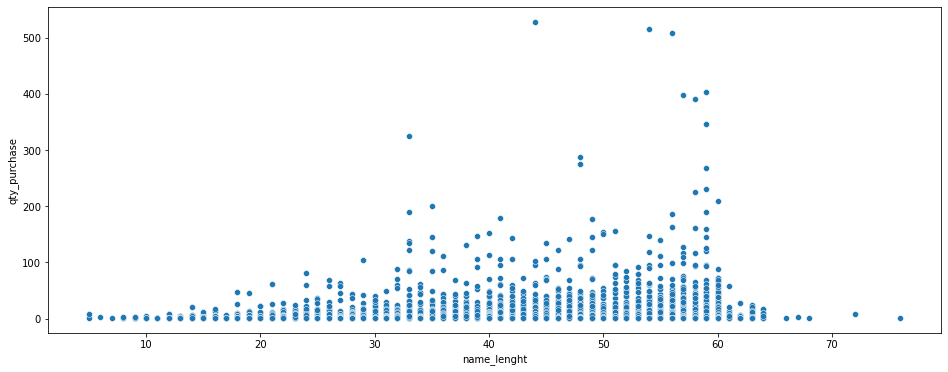

In [40]:
plt.figure(figsize=(16, 6))
sns_plot = sns.scatterplot(data=h9, x="name_lenght", y="qty_purchase");
sns_plot.figure.savefig("images/h9.png")

Hipótese falsa, existe exemplos de produtos com nomes longos onde vendeu uma quantidade bem alta.

**H10. Produtos com descrição longas são os mais vendidos**

In [41]:
h10 = df_ecommerce_engi[['product_id', 'product_description_lenght']].copy()
h10.head()

,product_id,product_description_lenght
0,87285b34884572647811a353c7ac498a,268.0
1,87285b34884572647811a353c7ac498a,268.0
2,87285b34884572647811a353c7ac498a,268.0
3,87285b34884572647811a353c7ac498a,268.0
4,87285b34884572647811a353c7ac498a,268.0


In [42]:
h10 = h10.groupby('product_id').agg(desc_lenght=('product_description_lenght', 'first'), qty_purchase=('product_id', 'count')).reset_index()

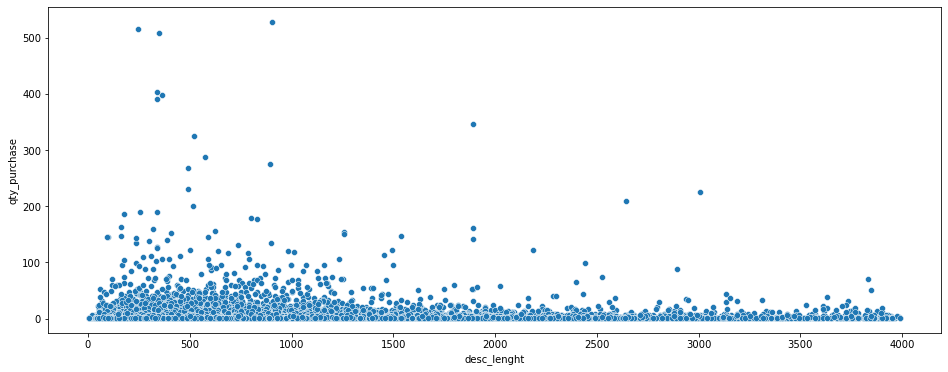

In [43]:
plt.figure(figsize=(16, 6))
sns_plot = sns.scatterplot(data=h10, x="desc_lenght", y="qty_purchase");
sns_plot.figure.savefig("images/h10.png")

Hipótese falsa, quanto maior o tamanho da descrição do produto menor é a quantidade vendida desse produto.

**H11. Produtos com grandes dimensões(altura, peso, largura...) são menos vendidos, porém tem alto retorno pro negócio** 

In [44]:
h11 = df_ecommerce_engi[['product_id', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'payment_value']].copy()

In [45]:
h11['is_product_large'] = h11.apply(lambda x: 1 if (x['product_weight_g']>10000) & (x['product_length_cm']>60) 
                 & (x['product_height_cm']>60) & (x['product_width_cm']>60) else 0, axis = 1)

In [46]:
h11 = h11.groupby(['product_id', 'is_product_large']).agg(total_value=('payment_value', 'sum'), qty_purchase=('product_id', 'count')).reset_index()

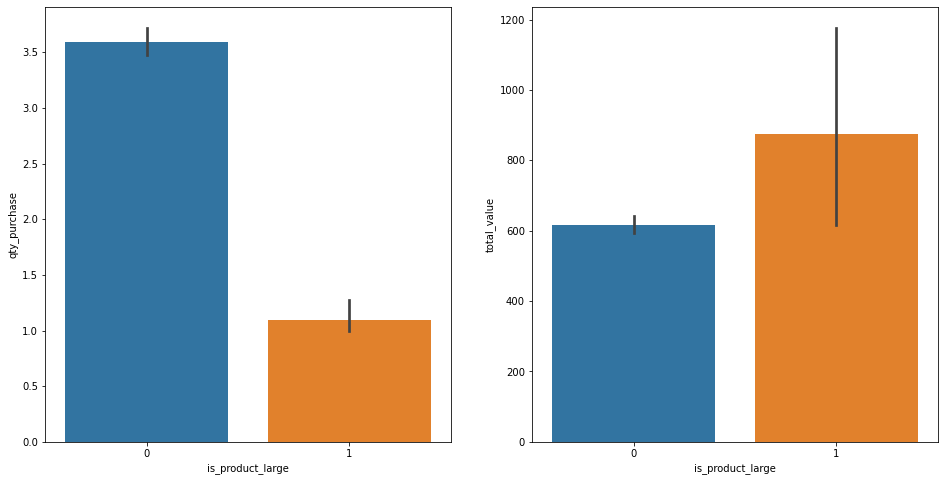

In [49]:
plt.subplots(figsize=(16,8))

# 1st plot
plt.subplot(1, 2, 1)
sns.barplot(data=h11, x="is_product_large", y="qty_purchase")


# 2nd plot
plt.subplot(1, 2, 2)
sns.barplot(data=h11, x="is_product_large", y="total_value");

Definindo que, produtos com grandes dimensões:
- Peso acima de 10000 gramas (10kg)
- Comprimento acima de 60cm
- Altura acima de 60cm
- Largura acima de 60cm

Dado isso temos que, a hipótese é verdadeira, vemos no gráfico que os produtos grandes tem uma baixa quantidades vendidas mas tem um valor total maior que o restante dos produtos.

**H12. Vendedores de SP são os que mais atrasam os envios**

In [50]:
h12 = df_ecommerce_engi[['seller_id', 'seller_state', 'order_delivered_customer_date', 'order_estimated_delivery_date']].copy()

In [51]:
h12 = h12.groupby(['seller_id', 'seller_state', 'order_delivered_customer_date', 'order_estimated_delivery_date']).first().reset_index()

In [52]:
h12['delay_delivered_estimated'] = h12.apply(lambda x : 1 if x['order_delivered_customer_date']> x['order_estimated_delivery_date'] else 0, axis=1)

In [53]:
h12.head()

,seller_id,seller_state,order_delivered_customer_date,order_estimated_delivery_date,delay_delivered_estimated
0,0015a82c2db000af6aaaf3ae2ecb0532,SP,2017-10-07,2017-10-30,0
1,0015a82c2db000af6aaaf3ae2ecb0532,SP,2017-10-24,2017-11-06,0
2,0015a82c2db000af6aaaf3ae2ecb0532,SP,2017-10-27,2017-11-09,0
3,001cca7ae9ae17fb1caed9dfb1094831,ES,2017-02-23,2017-03-21,0
4,001cca7ae9ae17fb1caed9dfb1094831,ES,2017-03-06,2017-03-13,0


In [54]:
h12 = h12.groupby('seller_state').agg(qty_delayed=('delay_delivered_estimated', 'count')).reset_index().sort_values('qty_delayed', ascending = False)

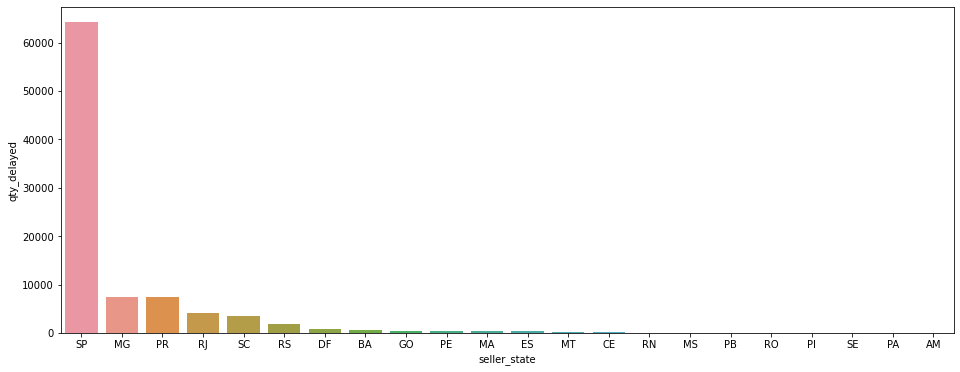

In [55]:
plt.figure(figsize=(16, 6))
sns_plot = sns.barplot(data=h12, x="seller_state", y="qty_delayed");
sns_plot.figure.savefig("images/h12.png")

Hipótese verdadeira, os vendedores do estado de SP são os vendedores que mais atrasam o pedido do cliente.

**H13. Os melhores vendedores, de acordo com a nota do review, são os que mais vendem produtos**

In [56]:
h13 = df_ecommerce_engi[['seller_id', 'review_score', 'product_id']].copy()
h13.head()

,seller_id,review_score,product_id
0,3504c0cb71d7fa48d967e0e4c94d59d9,4,87285b34884572647811a353c7ac498a
1,3504c0cb71d7fa48d967e0e4c94d59d9,4,87285b34884572647811a353c7ac498a
2,3504c0cb71d7fa48d967e0e4c94d59d9,4,87285b34884572647811a353c7ac498a
3,3504c0cb71d7fa48d967e0e4c94d59d9,4,87285b34884572647811a353c7ac498a
4,3504c0cb71d7fa48d967e0e4c94d59d9,5,87285b34884572647811a353c7ac498a


In [57]:
h13 = h13.groupby('seller_id').agg(avg_review_score=('review_score', 'mean'), qty_product=('product_id', 'count')).reset_index()

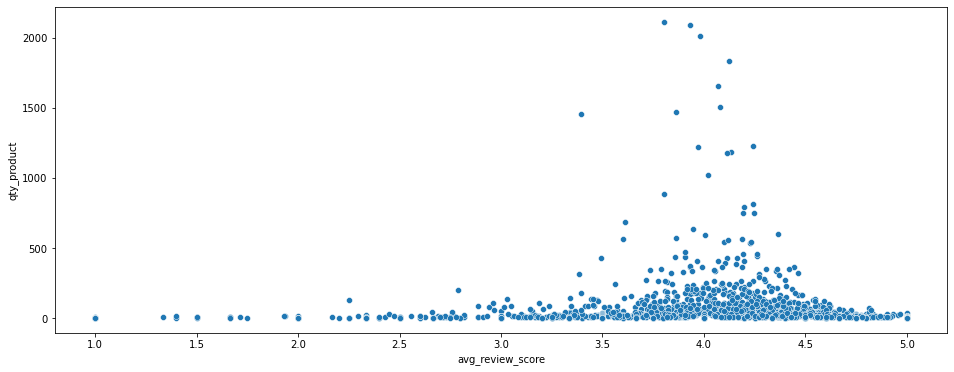

In [58]:
plt.figure(figsize=(16, 6))
sns_plot = sns.scatterplot(data=h13, x='avg_review_score', y='qty_product');
sns_plot.figure.savefig("images/h13.png")

Hipótese falsa, vemos que existe um comportamento onde quanto maior a nota do vendedor, menor é a quantidade de produtos vendidos por ele, como exemplo os vendedores com nota entre 4,5 e 5, vendem menos que os vendedores com nota 4. Podemos explica isso também pela quantidade de vendedores que temos com nota maior que 4,5.

**H14. Todas as compras feitas foram parceladas em 2x**

In [59]:
h14 = df_ecommerce_engi[['payment_installments']].copy()
h14.head()

,payment_installments
0,1
1,1
2,1
3,3
4,1


In [60]:
h14 = h14.groupby('payment_installments').agg(qty_installments=('payment_installments', 'count')).reset_index().sort_values('qty_installments', ascending = False)

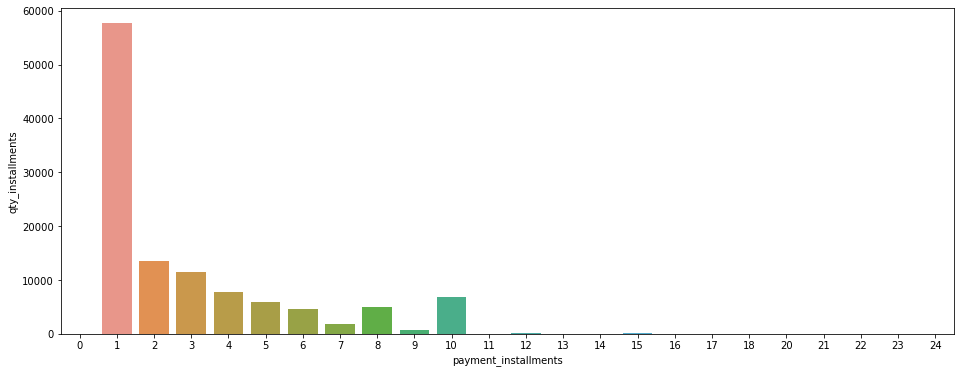

In [61]:
plt.figure(figsize=(16, 6))
sns_plot = sns.barplot(data=h14, x="payment_installments", y="qty_installments");
sns_plot.figure.savefig("images/h14.png")

Hipótese falsa, as compras são feitas parceladas em diversas parcelas, e fica evidente que a maioria das parcelas não são parceladas, somente 1x.

**H15. Quanto mais alta são as notas dos reviews menor as parcelas**

In [62]:
h15 = df_ecommerce_engi[['review_score', 'payment_installments']].copy()
h15.head()

,review_score,payment_installments
0,4,1
1,4,1
2,4,1
3,4,3
4,5,1


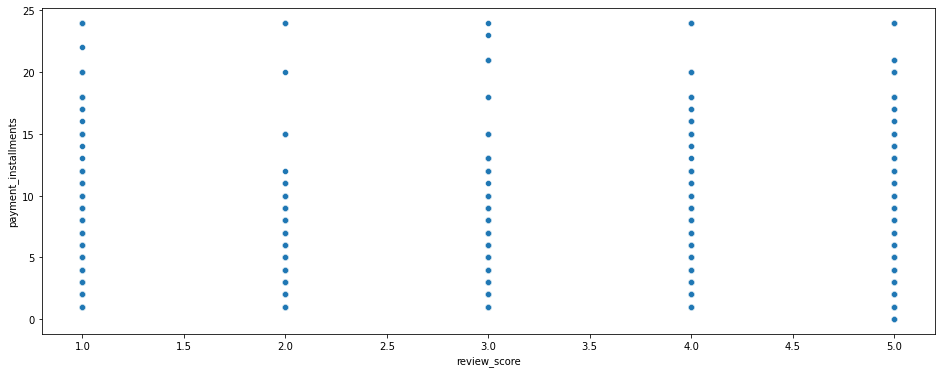

In [64]:
plt.figure(figsize=(16, 6))
sns_plot = sns.scatterplot(data = h15, x='review_score', y='payment_installments');
sns_plot.figure.savefig("images/h15.png")

Hipótese falsa, não há evidências o suficiente para confirmar que quanto mais alta são as notas dos reviews menor as parcelas, vemos que não importa a nota do review, vamos ter compras com diversas quantidade de parcelas.

**H16. Cartão de crédito é o método de pagamento que mais atrasa o envio para transportadora**

In [65]:
h16 = df_ecommerce_engi[['payment_type', 'order_delivered_carrier_date', 'order_estimated_delivery_date']].copy()
h16.head()

,payment_type,order_delivered_carrier_date,order_estimated_delivery_date
0,credit_card,2017-10-04,2017-10-18
1,voucher,2017-10-04,2017-10-18
2,voucher,2017-10-04,2017-10-18
3,credit_card,2017-08-17,2017-08-28
4,credit_card,2017-08-04,2017-08-15


In [66]:
h16 = h16.loc[h16['order_delivered_carrier_date']>h16['order_estimated_delivery_date']].groupby('payment_type').agg(count=('payment_type', 'count')).reset_index()

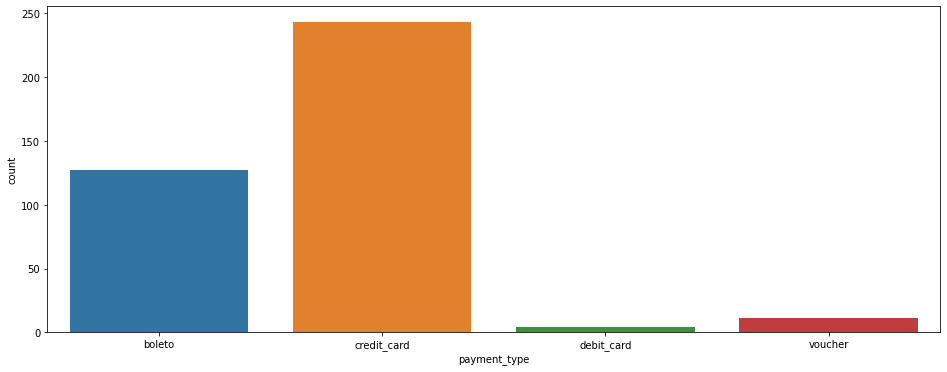

In [67]:
plt.figure(figsize=(16, 6))
sns_plot = sns.barplot(data=h16, x="payment_type", y="count");
sns_plot.figure.savefig("images/h16.png")

Hipótese verdadeira, vemos que o cartão de crédito é o método de pagamento que mais atrasa o envio para transportadora, isso é resultado de que a maioria das compras feitas na Olist são feitas com cartão de crédito, crescendo a quantidade de atrasos.

**H17. A maioria das compras são feitas antes do dia 15**

In [68]:
h17 = df_ecommerce_engi[['order_id', 'order_purchase_timestamp']].copy()
h17['day'] = df_ecommerce_engi['order_purchase_timestamp'].dt.day
h17.head()

,order_id,order_purchase_timestamp,day
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02,2
1,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02,2
2,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02,2
3,128e10d95713541c87cd1a2e48201934,2017-08-15,15
4,0e7e841ddf8f8f2de2bad69267ecfbcf,2017-08-02,2


In [69]:
h17 = h17.groupby('day').agg(qty_orders=('order_id', 'nunique')).reset_index()

In [70]:
h17['qty_orders'].loc[h17['day']<= 15].sum()

48237

In [71]:
h17['qty_orders'].loc[h17['day']> 15].sum()

48223

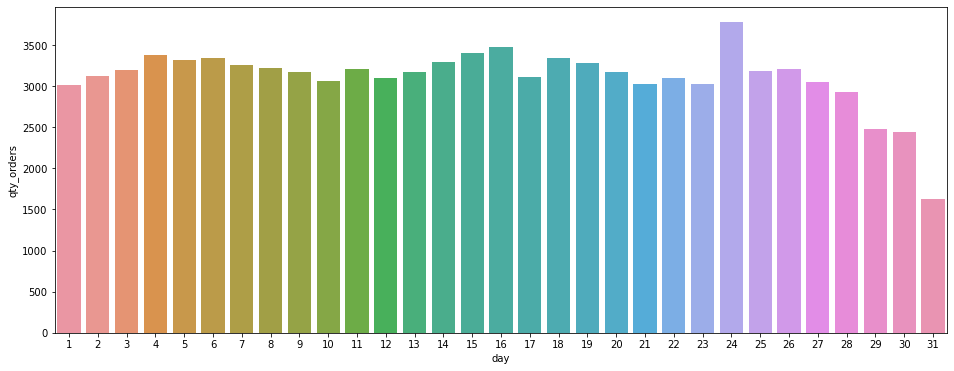

In [72]:
plt.figure(figsize=(16, 6))
sns_plot = sns.barplot(data=h17, x="day", y="qty_orders");
sns_plot.figure.savefig("images/h17.png")

Hipótese verdadeira, por bem pouco, as vendas são feitas antes do dia 15, porém bem apertado para as vendas após o dia 15, atenção nessa hipótese pois pode ser indício de poucos dados para tomar essa decisão. 

**H18. Há um aumento no valor de vendas aprovadas no mês de dezembro**

In [73]:
h18 = df_ecommerce_engi[['order_id', 'order_approved_at', 'payment_value']].copy()
h18['month'] = h18['order_approved_at'].dt.month_name()
h18['month_number'] = h18['order_approved_at'].dt.month
h18.head()

,order_id,order_approved_at,payment_value,month,month_number
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02,18.12,October,10
1,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02,2.00,October,10
2,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02,18.59,October,10
3,128e10d95713541c87cd1a2e48201934,2017-08-15,37.77,August,8
4,0e7e841ddf8f8f2de2bad69267ecfbcf,2017-08-02,37.77,August,8


In [74]:
h18 = h18.groupby(['month', 'month_number']).agg(total_value=('payment_value', 'sum')).reset_index().sort_values('month_number')

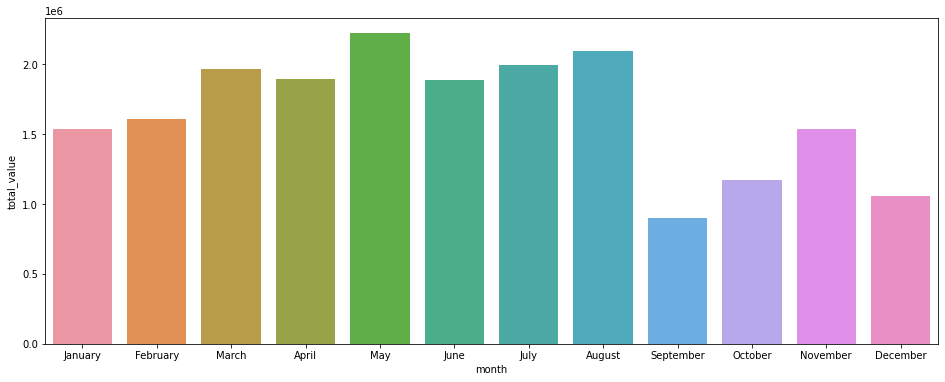

In [75]:
plt.figure(figsize=(16, 6))
sns_plot = sns.barplot(data=h18, x="month", y="total_value");
sns_plot.figure.savefig("images/h18.png")

Hipótese falsa, dentro de todos os meses dos anos que faz parte do nosso dataset, o mês de Dezembro é onde temos uma queda de vendas, comparado com o mês anterior. Podemos ver também que dezembro é o segundo mês que tem o menor valor total de vendas, somente atrás de setembro.

**H19. Os leads que não fecharam o negócio são os que foram adquiridos por pesquisa orgânica**

In [76]:
h19 = df_mkt_funnel.query('won_date != won_date')['origin']

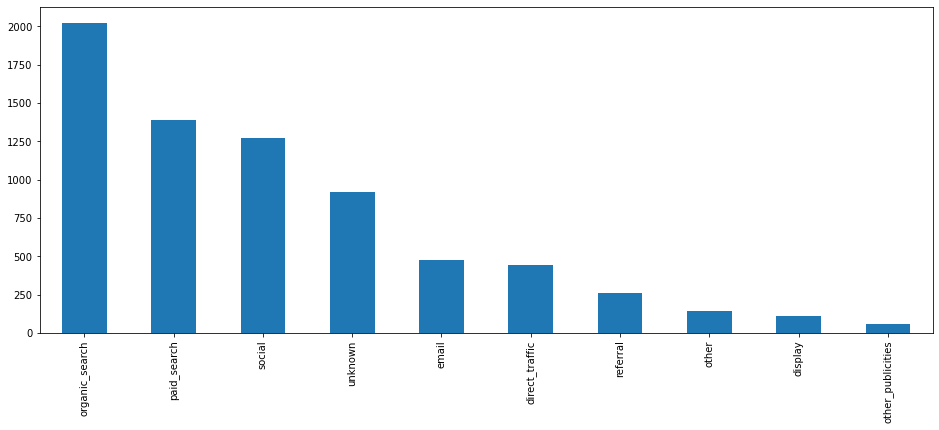

In [77]:
plt.figure(figsize=(16, 6))
sns_plot = h19.value_counts().plot(kind = 'bar');
sns_plot.figure.savefig("images/h19.png")

Hipótese falsa, mesmo que a origem dos leads que ainda não fecharam o negócio é pesquisa orgânica, ainda tem outras negócios não fechados para outras origens.

**H20. Os leads que tem uma empresa formal são a maioria que fecham o negócio**

In [250]:
df_mkt_funnel.loc[(df_mkt_funnel['has_company']==True) & (df_mkt_funnel['won_date'].notnull())].shape[0]

59

In [259]:
df_mkt_funnel.loc[(df_mkt_funnel['has_company']==False) & (df_mkt_funnel['won_date'].notnull())].shape[0]

29

Hipótese verdadeira, a maioria dos vendedores que pedem requisição para virar parceiro da empresa, a maioria que fecham o negócio são vendedores que possuem empresa formal.